Date: 24/2/2026

# Neural network for detecting credit card fraud from scratch

The task at hand is to create a 'simple' neural network with backpropagation 'from scratch' for our dataset of choice. Our chosen dataset is in this directory under card_transdata.csv. We already have made a thorough analysis which can be viewed in fraud.ipynb. The main takeaways are the following points:

* There are 7 features in total with 3 continuous features and 4 binary features.
* The 3 continuous features follow a powerlaw-distribution.
* There is a ~9:1 class inbalance for negative instances

Not only are we to set up, train and validate the neural network, we are also to investigate the research question: 
    
**How do varying degrees of label class imbalance affect training and performance of a neural network?**

This research question guides us to take a closer look at what is happening in the training stage and collect data on this so we can compare this data to the data collected from training the model on a slightly altered dataset with a different ratio of class imbalance.

Let's first start by splitting up our datasets. Our plain dataset has an approximate 9:91 (actually 8.74) split. 
For now, we will make two other datasets with the approximate splits: 4:96 and 14:86, but we may need more with different ratios, so we will write a general function for any split

To get the desired ratios we over- or undersample from the negative samples. We don't touch the positive samples because there are too few of them.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

# seed for randomness. Set manually for reproducability.
RANDOM_SEED = int(time.time_ns() % (2**32))
np.random.seed(RANDOM_SEED)

# load data
data = np.loadtxt('./card_transdata.csv', delimiter=',')

# take log of continuous features
data[:, 0:3] = np.log1p(data[:, 0:3])

# standardize continuous features with mean = 0 and var = 1
means = data[:, 0:3].mean(axis=0)
stds = data[:, 0:3].std(axis=0)

data[:, 0:3] = (data[:, 0:3] - means) / stds

# Split positive and negative instances
pos = data[data[:, 7] == 1]
neg = data[data[:, 7] == 0]

n_pos = len(pos)
n_neg = len(neg)

print(n_pos)
print(n_neg)

# general function for any ratio
def create_dataset_with_ratio(positives, negatives, target_ratio):
    
    P = len(positives)
    N_current = len(negatives)
    
    # Required number of negatives
    N_new = int((P / target_ratio) - P)
    
    if N_new <= 0:
        raise ValueError("Target ratio too large.")
    
    # Decide whether to oversample or undersample
    if N_new > N_current:
        # Oversampling → need replacement
        replace = True
    else:
        # Undersampling → no replacement
        replace = False
    
    selected_negatives = negatives[
        np.random.choice(len(negatives), size=N_new, replace=replace)
    ]
    
    new_data = np.vstack((positives, selected_negatives))
    np.random.shuffle(new_data)
    
    return new_data

# More imbalanced (~3.74% positive)
data_3_74 = create_dataset_with_ratio(pos, neg, 0.0374)

# Less imbalanced (~13.74% positive)
data_13_74 = create_dataset_with_ratio(pos, neg, 0.1374)

87403
912597


We now have three datasets. Lets put them in an array so we can loop over them. If we so desire, we can make a range of different datasets. This would be very, very memory intesive though.

We are almost done with preprocessing. We also have to split into train/validate/test and seperate out the labels.

In [7]:
all_sets = [data, data_3_74, data_13_74]
sets_with_split = []

def split_class(class_data):
    n = len(class_data)
    one_third = n // 3
    
    train = class_data[:one_third]
    val   = class_data[one_third:2*one_third]
    test  = class_data[2*one_third:]
    
    return train, val, test

# HYPERPARAMETER: train/validate/test split ratio. For now, I will do 1:1:1 split.
for data_set in all_sets:
    # Separate by class
    positives = data_set[data_set[:, 7] == 1]
    negatives = data_set[data_set[:, 7] == 0]
    
    # Shuffle each class separately
    np.random.shuffle(positives)
    np.random.shuffle(negatives)
    
    # Split classes
    pos_train, pos_val, pos_test = split_class(positives)
    neg_train, neg_val, neg_test = split_class(negatives)
    
    # Combine classes back together
    train = np.vstack((pos_train, neg_train))
    val   = np.vstack((pos_val,   neg_val))
    test  = np.vstack((pos_test,  neg_test))
    
    # Shuffle final sets
    np.random.shuffle(train)
    np.random.shuffle(val)
    np.random.shuffle(test)
    
    sets_with_split.append({
        'train': train,
        'val': val,
        'test': test
    })

for i, dataset_splits in enumerate(sets_with_split):
    print(f"\nDataset {i}:")
    print(f"  Train: {dataset_splits['train'].shape}")
    print(f"  Val:   {dataset_splits['val'].shape}")
    print(f"  Test:  {dataset_splits['test'].shape}")


Dataset 0:
  Train: (333333, 8)
  Val:   (333333, 8)
  Test:  (333334, 8)

Dataset 1:
  Train: (778992, 8)
  Val:   (778992, 8)
  Test:  (778994, 8)

Dataset 2:
  Train: (212039, 8)
  Val:   (212039, 8)
  Test:  (212042, 8)


The sizes of the sets have changed significantly. Especially the dataset with an even larger class inbalance is huge (more than doubled). This might be indication that we ought to change our approach to changing the class inbalance ratio as we now have a lot of redundancy in that dataset which may lead to overfitting. We could also test both methods: oversampling the negatives or undersampling the positives.

We now have our data prepared and our ducks in a row. We can start building the neural net.

The backpropagation algorithm goes, as specified in the slides, in the following steps:

* Do a forward pass.
* Start at the top (output) of your computation graph. (and store all intermediate values)
* Compute (and store) the derivative of every node.
* Work your way down (?). I assume this means perform gradient descent on the weights in the model after finding the gradient.

It is going to be harder to seperate the code snippets with markdown explanations from this point on. But I will try.

While writing the code, we came across an important consideration which we hadn't thought of before: the initialization strategy. Some research revealed something called the **Xavier/Glorot initialization**(we can use this for citing) strategy which is just initializing randomly from a normal distribution with mean=0 and variance=(some function over the number of input nodes and the number of output nodes). We also learned that initializing the biases with 0 is generally ok.

Another thing we came across was the problem of vanishing or exploding gradients. However, since we are only doing one hidden layer, this shouldn't become a problem

The next code block initializes the model weights and biases

In [10]:
# another hyper parameter I will change the code at some point to put all the hyperparamers in one spot so we can easily tune them
N_hidden_nodes = 15
# we only do one hidden layer so no hyper parameter for that

model_weights =[]

# initialize weights for three models using the xavier/glorot initialization strategy
for i in range(0, 3):
    
    # Initialize weights for input -> hidden layer (input layer has a fixed size: 7)
    limit_1 = np.sqrt(6 / (7 + N_hidden_nodes))
    W1 = np.random.uniform(-limit_1, limit_1, (N_hidden_nodes, 7))
    b1 = np.zeros(N_hidden_nodes)
    
    # Initialize weights for hidden -> output layer (output layer has a fixed size: 1)
    limit_2 = np.sqrt(6 / (N_hidden_nodes + 1))
    W2 = np.random.uniform(-limit_2, limit_2, N_hidden_nodes)
    b2 = 0
    
    weights = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }
    
    model_weights.append(weights)

print(len(model_weights))


3


We now have the initial weights set. I believe that from this point on, we can completely perform the backprop algorithm. Lets start with a forward pass.

Another consideration is how we make the algorithm terminate. For now I will just let it run four epochs. At some point, we may want to make it terminate conditionally based on how much or how little the loss changes.

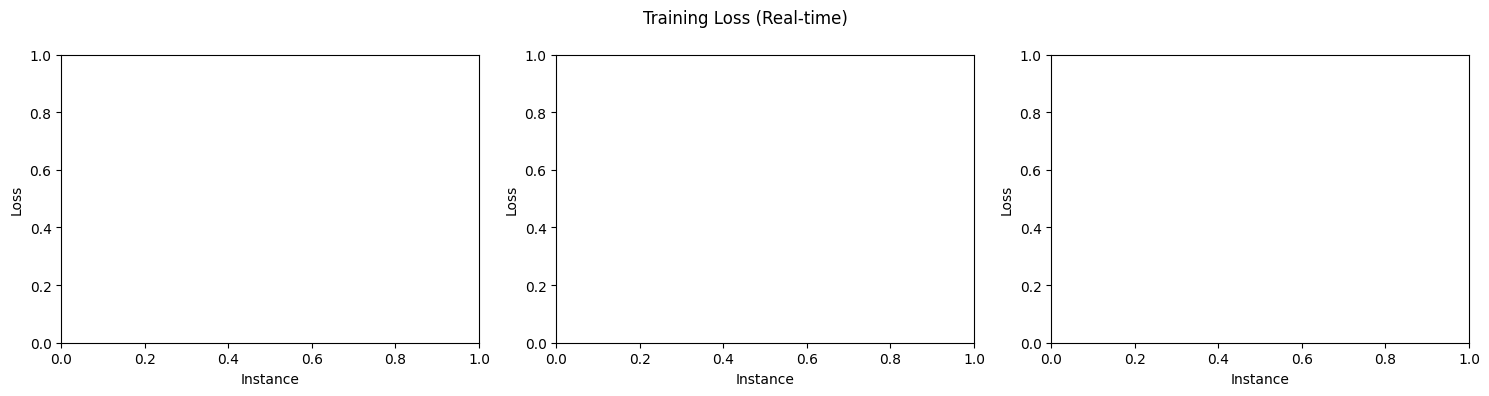

Dataset 0 | Epoch 1 | Instance 0
Dataset 0 | Epoch 1 | Instance 10000
Dataset 0 | Epoch 1 | Instance 20000
Dataset 0 | Epoch 1 | Instance 30000
Dataset 0 | Epoch 1 | Instance 40000
Dataset 0 | Epoch 1 | Instance 50000
Dataset 0 | Epoch 1 | Instance 60000
Dataset 0 | Epoch 1 | Instance 70000
Dataset 0 | Epoch 1 | Instance 80000
Dataset 0 | Epoch 1 | Instance 90000
Dataset 0 | Epoch 1 | Instance 100000
Dataset 0 | Epoch 1 | Instance 110000
Dataset 0 | Epoch 1 | Instance 120000
Dataset 0 | Epoch 1 | Instance 130000
Dataset 0 | Epoch 1 | Instance 140000
Dataset 0 | Epoch 1 | Instance 150000
Dataset 0 | Epoch 1 | Instance 160000
Dataset 0 | Epoch 1 | Instance 170000
Dataset 0 | Epoch 1 | Instance 180000
Dataset 0 | Epoch 1 | Instance 190000
Dataset 0 | Epoch 1 | Instance 200000
Dataset 0 | Epoch 1 | Instance 210000
Dataset 0 | Epoch 1 | Instance 220000
Dataset 0 | Epoch 1 | Instance 230000
Dataset 0 | Epoch 1 | Instance 240000
Dataset 0 | Epoch 1 | Instance 250000
Dataset 0 | Epoch 1 | Inst

In [14]:
# hyperparameters
from IPython.display import display

epochs = 2
learning_rate = 0.005

# code for plotting the loss
plt.ion()  # turn on interactive mode
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_histories = [[], [], []]

for ax in axes:
    ax.set_xlabel('Instance')
    ax.set_ylabel('Loss')
fig.suptitle('Training Loss (Real-time)')
plt.tight_layout()

plt.show()

# train for all ratios iteratively
for dataset_idx, (data_set, weights) in enumerate(zip(sets_with_split, model_weights)):
    for epoch in range(0, epochs):
        ''' 
        for now we do completely stochastically so we do gradient descent over all instances individually. 
        At some point we may want to do this in batches
        '''
        for instance_idx, instance in enumerate(data_set['train']):
            if instance_idx % 10000 == 0:
                print(f'Dataset {dataset_idx} | Epoch {epoch+1} | Instance {instance_idx}')

            # seperate out the features from the label
            x = instance[:7]
            t = instance[7]

            k = np.zeros(N_hidden_nodes)
            h = np.empty(N_hidden_nodes)

            y = 0
            y_sig = 0

            loss = 0

            # I know that this part can be done as a matrix operation instead of iteratively. And that this would make it vastly more efficient.
            for j in range(0, N_hidden_nodes):
                for i in range(0, 7):
                    # W1 has shape (N_hidden_nodes, 7) so we take x[i] * weights['W1'][j,i] not weights['W1'][i,j]
                    k[j] += x[i] * weights['W1'][j,i]
                k[j] += weights['b1'][j]

            for index, val in enumerate(k):
                h[index] = 1/(1 + np.exp(-val))

            for index, val in enumerate(h):
                y += val * weights['W2'][index]

            # final output value for the forward pass (sigmoid activation for binary cross entropy)
            y_sig = 1/(1 + np.exp(-y))

            # we may want to plot the loss or the average loss of the epoch or the loss of a batch over time
            loss = -(t * np.log(y_sig) + (1 - t) * np.log(1 - y_sig))

            # code for plotting
            loss_histories[dataset_idx].append(loss)

            # update plot every 500 instances to avoid slowdown
            if len(loss_histories[dataset_idx]) % 500 == 0:
                ax = axes[dataset_idx]
                ax.clear()
                ax.plot(loss_histories[dataset_idx], linewidth=0.5)
                ax.set_title(f'Model {dataset_idx} | Epoch {epoch+1}')
                ax.set_xlabel('Instance')
                ax.set_ylabel('Loss')
                fig.canvas.draw()
                fig.canvas.flush_events()

            '''
            End of the forward pass. 
            We must now compute the derivatives of the loss with respect to every node of the computation graph.
            '''

            # The derivative of BCE with respect to the sigmoid of the output is simply the predicted probability minus the label. (sigmoid(y) - t)
            # In other words, we can skip over one node in the computation graph.
            d_y = y_sig - t
            
            d_h = np.empty(N_hidden_nodes)
            d_w2 = np.empty(N_hidden_nodes) #this one

            for index, (w2_i, h_i) in enumerate(zip(weights['W2'], h)):
                d_h[index] = d_y * w2_i
                d_w2[index] = d_y * h_i
            
            d_b2 = d_y #this one

            d_k = np.empty(N_hidden_nodes)

            for index, (d_h_i, h_i) in enumerate(zip(d_h, h)):
                d_k[index] = d_h_i * h_i * (1 - h_i)
            
            d_w1 = np.empty((N_hidden_nodes, 7)) #this one
            d_b1 = np.empty(N_hidden_nodes) #this one

            for j, d_k_j in enumerate(d_k):
                for i, x_i in enumerate(x):
                    d_w1[j,i] = d_k_j * x_i
                d_b1[j] = d_k_j

            '''
            End of the backwards pass.
            For each new derivative for the model weights, we must now perform gradient descent.
            '''

            for index, d_w2_i in enumerate(d_w2):
                weights['W2'][index] -= learning_rate * d_w2_i

            weights['b2'] -= learning_rate * d_b2

            for j in range(N_hidden_nodes):
                for i in range(7):
                    weights['W1'][j,i] -= learning_rate * d_w1[j,i]

            for d_b1_i in d_b1:
                weights['b1'] -= learning_rate * d_b1_i

            '''
            End of the gradient descent step.
            '''

            
            

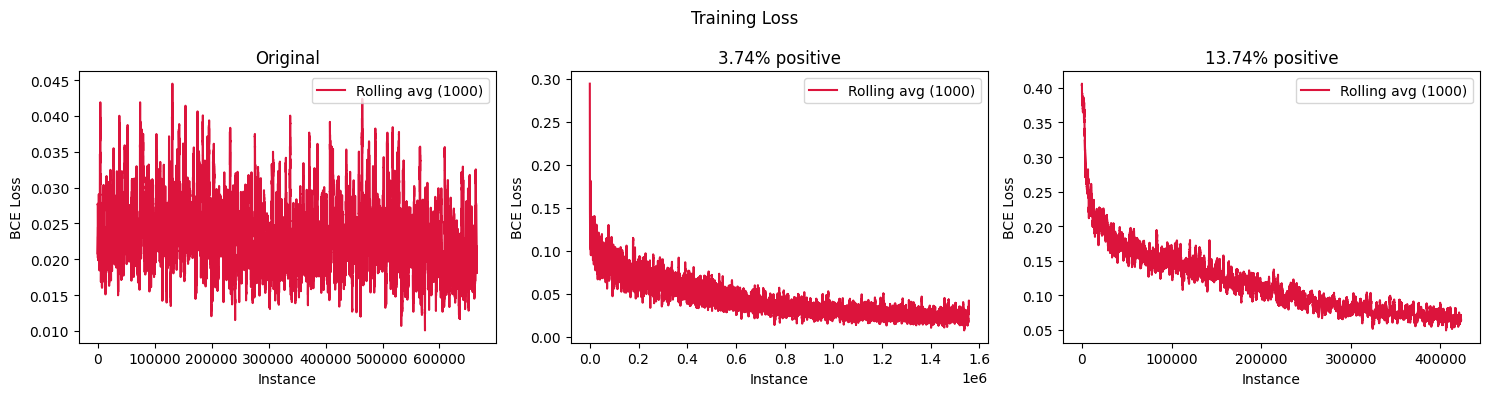

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Original', '3.74% positive', '13.74% positive']

for idx, (ax, history, label) in enumerate(zip(axes, loss_histories, labels)):
    # ax.plot(history, linewidth=0.5, alpha=0.4, color='steelblue', label='Raw loss')
    
    # rolling average to see trend through the noise
    window = 1000
    if len(history) >= window:
        rolling = np.convolve(history, np.ones(window)/window, mode='valid')
        ax.plot(rolling, linewidth=1.5, color='crimson', label=f'Rolling avg ({window})')
    
    ax.set_title(label)
    ax.set_xlabel('Instance')
    ax.set_ylabel('BCE Loss')
    ax.legend()

fig.suptitle('Training Loss')
plt.tight_layout()
plt.show()
